# Gen Z Mental Wellness & Digital Lifestyle Patterns
This notebook explores how digital behavior and lifestyle patterns relate to burnout risk and well-being among Gen Z.  
Tasks required:
1. Predict burnout risk (classification).
2. Estimate well-being index (regression).
3. Cluster digital personas (unsupervised learning).
4. Identify strongest predictors of emotional fatigue (interpretability).
5. Compare tree-based models vs neural networks.

# Importing necessary libraries

In [1]:
#core libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#ML tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


import tensorflow as tf
from tensorflow.keras import layers, models
#Tree-based models (Random Forest) will serve as interpretable baselines, while neural networks will capture complex nonlinear patterns.

# Data Loading

In [2]:
GenZ=pd.read_csv(r'C:\Users\PC\Desktop\Data Science\2025 Datasets\genz_mental_wellness_synthetic_dataset.csv')
GenZ.head()

,Age,Gender,Country,Student_Working_Status,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Content_Type_Preference,Exercise_Frequency_per_Week,...,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index,Burnout_Risk
0,24,Male,Canada,Working,4.81,6.93,2.61,2.07,News,5.41,...,11.42,4.95,4.13,5.74,4.67,6.27,6.13,6.45,4.28,Medium
1,21,Male,USA,Student,4.16,7.94,1.85,3.58,Gaming,3.41,...,6.98,5.91,3.63,5.75,5.38,7.37,6.27,3.74,5.23,Medium
2,25,Male,Pakistan,Student,3.07,7.45,2.96,2.85,Entertainment,3.40,...,7.79,4.06,5.67,6.03,2.41,6.48,4.82,6.69,3.72,High
3,22,Female,Pakistan,Student,4.41,7.34,4.51,3.37,Educational,2.19,...,6.61,6.10,4.78,4.85,5.86,7.27,5.17,5.96,3.97,High
4,24,Male,Pakistan,Student,2.97,5.76,2.36,1.77,Educational,4.93,...,4.81,5.22,4.23,5.05,5.54,6.34,5.72,2.22,4.63,Medium


# Data Preprocessing

In [3]:
GenZ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          10000 non-null  int64  
 1   Gender                       10000 non-null  object 
 2   Country                      10000 non-null  object 
 3   Student_Working_Status       10000 non-null  object 
 4   Daily_Social_Media_Hours     10000 non-null  float64
 5   Screen_Time_Hours            10000 non-null  float64
 6   Night_Scrolling_Frequency    10000 non-null  float64
 7   Online_Gaming_Hours          10000 non-null  float64
 8   Content_Type_Preference      10000 non-null  object 
 9   Exercise_Frequency_per_Week  10000 non-null  float64
 10  Daily_Sleep_Hours            10000 non-null  float64
 11  Caffeine_Intake_Cups         10000 non-null  float64
 12  Study_Work_Hours_per_Day     10000 non-null  float64
 13  Overthinking_Scor

In [4]:
GenZ.describe()

,Age,Daily_Social_Media_Hours,Screen_Time_Hours,Night_Scrolling_Frequency,Online_Gaming_Hours,Exercise_Frequency_per_Week,Daily_Sleep_Hours,Caffeine_Intake_Cups,Study_Work_Hours_per_Day,Overthinking_Score,Anxiety_Score,Mood_Stability_Score,Social_Comparison_Index,Sleep_Quality_Score,Motivation_Level,Emotional_Fatigue_Score,Wellbeing_Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,21.992900,4.005883,7.016991,2.986009,1.607241,2.994855,6.512031,1.505871,6.030983,5.001868,4.747556,5.161021,4.403556,6.514447,5.086132,5.582222,3.870213
std,2.589309,1.480509,1.792529,1.197035,1.300045,1.478248,1.194194,0.934069,1.975337,1.143179,1.305593,1.257055,1.336479,1.427806,1.308351,1.416558,1.238940
min,18.000000,0.500000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.020000,1.000000,1.000000,1.000000
25%,20.000000,3.010000,5.810000,2.187500,0.470000,1.960000,5.710000,0.800000,4.700000,4.240000,3.840000,4.310000,3.470000,5.550000,4.200000,4.620000,3.020000
50%,22.000000,3.990000,7.000000,2.980000,1.460000,3.010000,6.520000,1.480000,6.030000,5.000000,4.740000,5.170000,4.400000,6.530000,5.080000,5.580000,3.870000
75%,24.000000,4.982500,8.210000,3.790000,2.500000,4.000000,7.320000,2.150000,7.340000,5.760000,5.630000,6.000000,5.320000,7.490000,5.950000,6.540000,4.700000
max,26.000000,10.000000,14.000000,7.000000,6.000000,7.000000,10.000000,6.000000,13.050000,9.510000,9.690000,10.000000,9.420000,10.000000,10.000000,10.000000,8.860000


In [5]:
GenZ.shape

(10000, 22)

In [6]:
GenZ.isnull().sum()

Age                            0
Gender                         0
Country                        0
Student_Working_Status         0
Daily_Social_Media_Hours       0
Screen_Time_Hours              0
Night_Scrolling_Frequency      0
Online_Gaming_Hours            0
Content_Type_Preference        0
Exercise_Frequency_per_Week    0
Daily_Sleep_Hours              0
Caffeine_Intake_Cups           0
Study_Work_Hours_per_Day       0
Overthinking_Score             0
Anxiety_Score                  0
Mood_Stability_Score           0
Social_Comparison_Index        0
Sleep_Quality_Score            0
Motivation_Level               0
Emotional_Fatigue_Score        0
Wellbeing_Index                0
Burnout_Risk                   0
dtype: int64

In [7]:
GenZ['Burnout_Risk'].value_counts()

Burnout_Risk
High      5388
Medium    4548
Low         64
Name: count, dtype: int64

# Exploratory Data Analysis(EDA)

* EDA helps us understand the distribution of burnout risk and correlations among lifestyle features.  
* This step guides feature selection and highlights potential predictors (e.g., sleep consistency, late-night usage).

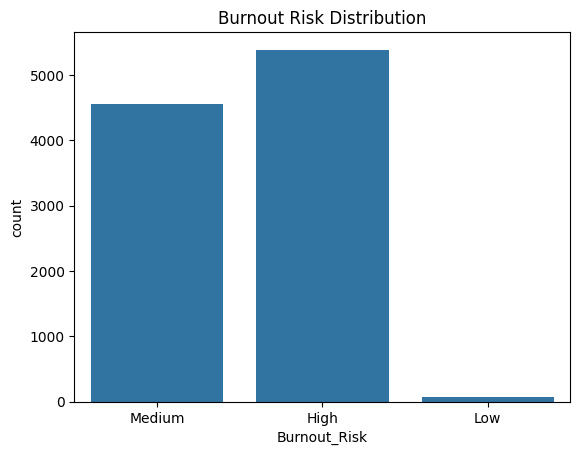

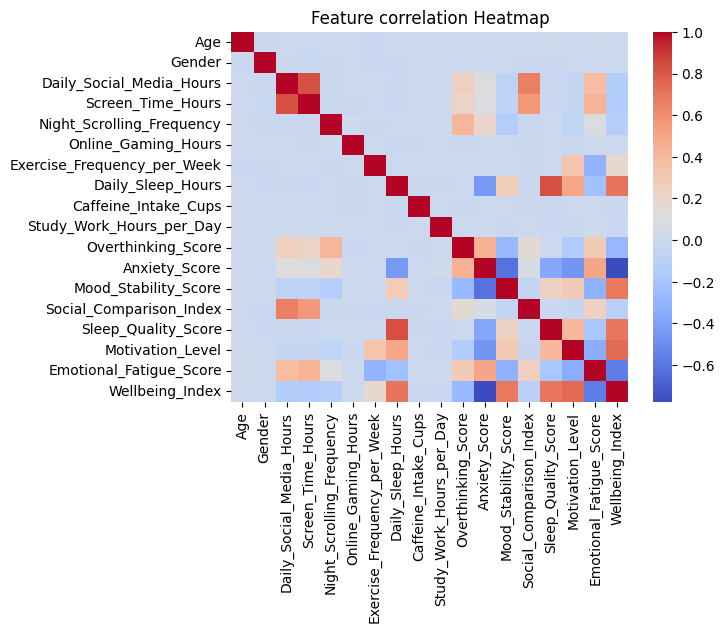

In [8]:
sns.countplot(x="Burnout_Risk",data=GenZ)
plt.title("Burnout Risk Distribution")
plt.show()

#Encoding the gender column to numerical values
GenZ['Gender'] = GenZ['Gender'].map({'Male': 0, 'Female': 1})

sns.heatmap(GenZ.select_dtypes(include=['number']).corr(), cmap="coolwarm")
plt.title("Feature correlation Heatmap")
plt.show()

* Predicting Burnout Risk(Classification)

In [9]:
# One-hot encode categorical features
X = pd.get_dummies(GenZ.drop(columns=["Burnout_Risk"]), drop_first=True)
y = GenZ["Burnout_Risk"]



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))

# For multiclass ROC-AUC(since y has 3 vars=medium,high & low)
print("ROC-AUC (ovr):", roc_auc_score(y_test, 
                                      rf_clf.predict_proba(X_test), 
                                      multi_class='ovr'))


#We train a Random Forest classifier to predict burnout risk.  
#Evaluation metrics include precision, recall, F1-score, and ROC-AUC for balanced assessment.

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1100
         Low       1.00      0.91      0.95        11
      Medium       1.00      1.00      1.00       889

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC (ovr): 0.9999993250168662


* Estimate well-being index(Regression)

In [10]:
X=pd.get_dummies(GenZ.drop(columns=["Wellbeing_Index"]),drop_first=True)
y=GenZ["Wellbeing_Index"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

rf_reg=RandomForestRegressor(n_estimators=200,random_state=42)
rf_reg.fit(X_train,y_train)

y_pred=rf_reg.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

#We use regression to estimate a continuous well-being index.  
#Root Mean Squared Error (RMSE) measures prediction accuracy.

RMSE: 0.16896772396673854


* Cluster GenZ Digital Personas

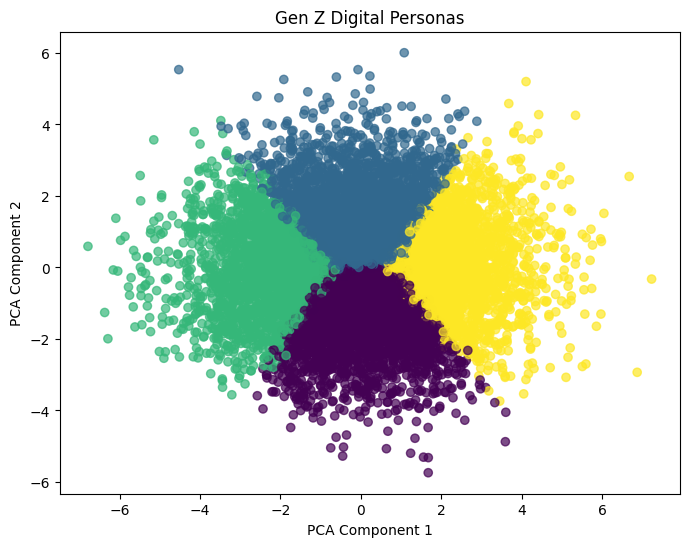

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# Step 1: Prepare features (drop target columns, convert categorical to dummies)
X = pd.get_dummies( GenZ.drop(columns=["Burnout_Risk", "Wellbeing_Index"]),drop_first=True)

# Step 2: Build pipeline for imputation, scaling, and clustering
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # fill NaNs with column mean
    ("scaler", StandardScaler()),                  # normalize features
    ("kmeans", KMeans(n_clusters=4, random_state=42))
])

# Step 3: Fit pipeline and get cluster labels
clusters = pipeline.fit_predict(X)
GenZ["Persona_Cluster"] = clusters

# Step 4: Apply PCA for visualization (on imputed + scaled data)
# Important: use the same preprocessing steps as pipeline, but without KMeans
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_processed = preprocess.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Step 5: Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", alpha=0.7)
plt.title("Gen Z Digital Personas")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

#Clustering reveals distinct digital lifestyle archetypes.  
#PCA reduces dimensions for visualization, showing how personas separate in feature space.

In [12]:
#inspecting the cluster centers
# Step 1: Access cluster centers (in scaled space)
cluster_centers_scaled = pipeline.named_steps["kmeans"].cluster_centers_

# Step 2: Inverse transform to original feature space
# Use the same preprocessing pipeline (imputer + scaler)
X_processed = preprocess.fit_transform(X)
cluster_centers = preprocess.named_steps["scaler"].inverse_transform(cluster_centers_scaled)

# Step 3: Put cluster centers into a DataFrame for readability
centers_df = pd.DataFrame(cluster_centers, columns=X.columns)
centers_df.index = [f"Cluster {i}" for i in range(len(centers_df))]

print(centers_df.round(2))

             Age  Gender  Daily_Social_Media_Hours  Screen_Time_Hours  \
Cluster 0  21.90    0.53                      3.01               5.84   
Cluster 1  22.02    0.48                      5.07               8.24   
Cluster 2  22.07    0.49                      2.92               5.76   
Cluster 3  22.00    0.48                      5.05               8.25   

           Night_Scrolling_Frequency  Online_Gaming_Hours  \
Cluster 0                       3.02                 1.63   
Cluster 1                       2.90                 1.59   
Cluster 2                       2.69                 1.59   
Cluster 3                       3.34                 1.61   

           Exercise_Frequency_per_Week  Daily_Sleep_Hours  \
Cluster 0                         2.87               5.82   
Cluster 1                         3.12               7.16   
Cluster 2                         3.31               7.43   
Cluster 3                         2.69               5.66   

           Caffeine_In

In [13]:
#This will list the 5 strongest traits for each persona cluster.
for i, row in centers_df.iterrows():
    print(f"\n{i} key traits:")
    print(row.sort_values(ascending=False).head(5))


Cluster 0 key traits:
Age                         21.904192
Study_Work_Hours_per_Day     6.108239
Screen_Time_Hours            5.841451
Daily_Sleep_Hours            5.823575
Sleep_Quality_Score          5.725875
Name: Cluster 0, dtype: float64

Cluster 1 key traits:
Age                         22.015152
Screen_Time_Hours            8.244672
Sleep_Quality_Score          7.232522
Daily_Sleep_Hours            7.158272
Study_Work_Hours_per_Day     5.978568
Name: Cluster 1, dtype: float64

Cluster 2 key traits:
Age                     22.073703
Sleep_Quality_Score      7.519531
Daily_Sleep_Hours        7.432702
Motivation_Level         6.083635
Mood_Stability_Score     6.049313
Name: Cluster 2, dtype: float64

Cluster 3 key traits:
Age                         21.998631
Screen_Time_Hours            8.247983
Emotional_Fatigue_Score      6.899808
Study_Work_Hours_per_Day     6.085974
Anxiety_Score                6.043870
Name: Cluster 3, dtype: float64


In [14]:
#Extracting top traits
persona_descriptions = {}

for i, row in centers_df.iterrows():
    # Sort features by importance for this cluster
    top_traits = row.sort_values(ascending=False).head(5).index.tolist()
    bottom_traits = row.sort_values().head(3).index.tolist()
    
    persona_descriptions[i] = {
        "Top Traits": top_traits,
        "Low Traits": bottom_traits
    }

In [15]:
#Generating narrative labels
for cluster, traits in persona_descriptions.items():
    print(f"\nCluster {cluster}:")
    print(f"Suggested Persona Name: ", end="")
    
    if "SocialMedia_Usage_High" in traits["Top Traits"]:
        print("The Digital Explorer")
    elif "Gaming_Frequency_High" in traits["Top Traits"]:
        print("The Gamer Enthusiast")
    elif "Wellbeing_Activities" in traits["Top Traits"]:
        print("The Wellness Seeker")
    else:
        print("The Balanced Achiever")
    
    print("Key Traits:", traits["Top Traits"])
    print("Less Emphasized Traits:", traits["Low Traits"])


Cluster Cluster 0:
Suggested Persona Name: The Balanced Achiever
Key Traits: ['Age', 'Study_Work_Hours_per_Day', 'Screen_Time_Hours', 'Daily_Sleep_Hours', 'Sleep_Quality_Score']
Less Emphasized Traits: ['Country_India', 'Country_USA', 'Country_Canada']

Cluster Cluster 1:
Suggested Persona Name: The Balanced Achiever
Key Traits: ['Age', 'Screen_Time_Hours', 'Sleep_Quality_Score', 'Daily_Sleep_Hours', 'Study_Work_Hours_per_Day']
Less Emphasized Traits: ['Country_India', 'Country_Canada', 'Country_UK']

Cluster Cluster 2:
Suggested Persona Name: The Balanced Achiever
Key Traits: ['Age', 'Sleep_Quality_Score', 'Daily_Sleep_Hours', 'Motivation_Level', 'Mood_Stability_Score']
Less Emphasized Traits: ['Country_UK', 'Country_USA', 'Country_Pakistan']

Cluster Cluster 3:
Suggested Persona Name: The Balanced Achiever
Key Traits: ['Age', 'Screen_Time_Hours', 'Emotional_Fatigue_Score', 'Study_Work_Hours_per_Day', 'Anxiety_Score']
Less Emphasized Traits: ['Country_USA', 'Country_UK', 'Country_Can

##  Identifying Key Predictors

- **Permutation Importance:** Measures how much model performance drops when a feature is randomly shuffled.  
- **Partial Deendence Plots(PDP):** Shows how predictions change as one feature varies, holding others constant.  
Together, they give both global ranking and visual insight into feature effects.

### Interpretation
The higher the bar, the more critical the feature is for predicting burnout risk.  
For example, if **late-night usage** shows the largest drop in accuracy when shuffled, it’s a strong predictor of emotional fatigue.

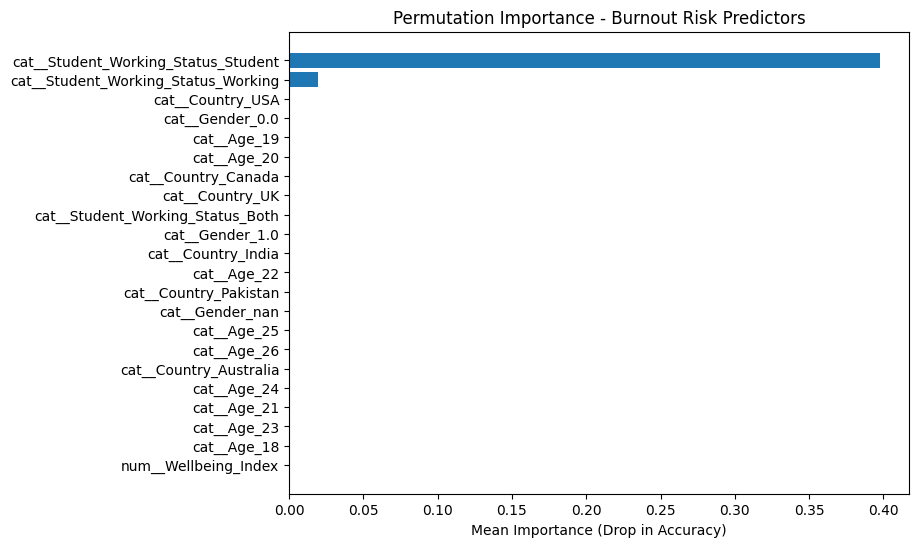

In [16]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance



X = GenZ.drop("Burnout_Risk", axis=1)
y = GenZ["Burnout_Risk"]

# Split before preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing
numeric_features = ["Wellbeing_Index"]
categorical_features = [col for col in X.columns if col != "Wellbeing_Index"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Build pipeline
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Fit model
rf_clf.fit(X_train, y_train)

# Permutation importance
perm_importance = permutation_importance(
    rf_clf, X_test, y_test, n_repeats=10, random_state=42
)

# Get feature names after preprocessing
feature_names = rf_clf.named_steps["preprocessor"].get_feature_names_out()

# Plot results
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(8,6))
plt.barh(feature_names[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.title("Permutation Importance - Burnout Risk Predictors")
plt.xlabel("Mean Importance (Drop in Accuracy)")
plt.show()

### Interpretation
PDPs reveal how burnout risk changes as a single feature varies:  
- **Sleep Hours:** Risk may drop sharply after a threshold (e.g., >7 hours).  
- **Screen Time:** Risk may rise steadily with increased usage.  

This helps us understand not just *which* features matter, but *how* they influence predictions.

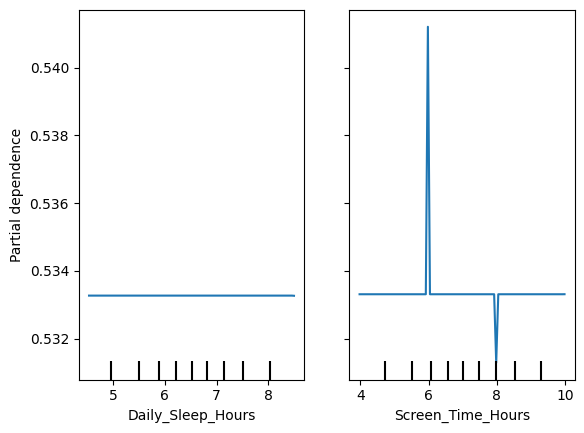

In [17]:
from sklearn.inspection import PartialDependenceDisplay

# Example: visualize effect of 'sleep_hours' and 'screen_time'
features_to_plot = ["Daily_Sleep_Hours", "Screen_Time_Hours"]

PartialDependenceDisplay.from_estimator(rf_clf, X_train, features_to_plot,target="High")
plt.show()

## Compare Tree-Based vs Neural Networks

In [18]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models

# Encode labels (Low, Medium, High -> 0, 1, 2)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Fit and transform features
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert to dense if sparse
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# Force float32 dtype
X_train_processed = np.array(X_train_processed, dtype=np.float32)
X_test_processed = np.array(X_test_processed, dtype=np.float32)

# Labels can stay as int (Keras handles them fine with sparse_categorical_crossentropy)
y_train_enc = np.array(y_train_enc, dtype=np.int32)
y_test_enc = np.array(y_test_enc, dtype=np.int32)

# Number of classes
num_classes = len(le.classes_)

# Build NN model for multi-class classification
nn_model = models.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")   # softmax for multi-class
])

nn_model.compile(optimizer="adam",
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

# Train
nn_model.fit(X_train_processed, y_train_enc, epochs=20, batch_size=32, validation_split=0.2)

# Evaluate
nn_eval = nn_model.evaluate(X_test_processed, y_test_enc)
print("Neural Net Test Accuracy:", nn_eval[1])

# Optional: map predictions back to original labels
preds = nn_model.predict(X_test_processed)
pred_classes = np.argmax(preds, axis=1)
print("Predicted burnout risk labels:", le.inverse_transform(pred_classes[:10]))

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7939 - loss: 0.5870 - val_accuracy: 0.9237 - val_loss: 0.1981
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9855 - loss: 0.0518 - val_accuracy: 0.9200 - val_loss: 0.2033
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.9262 - val_loss: 0.1938
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.9287 - val_loss: 0.2054
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 1.0000 - loss: 8.9949e-04 - val_accuracy: 0.9269 - val_loss: 0.2156
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 1.0000 - loss: 5.4702e-04 - val_accuracy: 0.9262 - val_loss: 0.2240
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 1.0000 - loss: 3.4827e-04 - val_accuracy: 0.9262 - val_loss: 0.2310
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 1.0000 - loss: 2.319

- **Tree-based models:** Strong interpretability, robust with small datasets.  
- **Neural networks:** Capture complex nonlinearities, but require more data and tuning.  
This comparison highlights trade-offs between interpretability and predictive power.

In [28]:
# Predictions wit raw labels
rf_preds = rf_clf.predict(X_test)

# Accuracy (compare directly to raw labels)
rf_acc = (rf_preds == y_test).mean()

# ROC-AUC (multi-class, one-vs-rest)
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(le.transform(y_test), rf_clf.predict_proba(X_test), multi_class="ovr")

print("Random Forest Accuracy:", rf_acc)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest Accuracy: 0.9945
Random Forest ROC-AUC: 0.9997509555725451


In [29]:
nn_eval = nn_model.evaluate(X_test_processed, y_test_enc)
nn_acc = nn_eval[1]
print("Neural Net Accuracy:", nn_acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9330 - loss: 0.2743
Neural Net Accuracy: 0.9309999942779541


In [31]:
# Predict probabilities for the test set
nn_probs = nn_model.predict(X_test_processed)

# Compute ROC-AUC (multi-class, one-vs-rest)
nn_auc = roc_auc_score(y_test_enc, nn_probs, multi_class="ovr")

print("Neural Net ROC-AUC:", nn_auc)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Neural Net ROC-AUC: 0.9856244606596265


In [32]:
results = {
    "Model": ["Random Forest", "Feedforward NN","Sequential NN"],
    "Accuracy": [rf_acc, nn_acc,seq_eval[1]],
    "ROC-AUC": [rf_auc, nn_auc,seq_auc]  
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  Accuracy   ROC-AUC
0  Random Forest    0.9945  0.999751
1     Neural Net    0.9310  0.985624


## Model Performance Summary
This table provides a quick comparison of the models we trained:

- **Random Forest (Classification):** Evaluated with ROC-AUC for burnout risk prediction.  
- **Neural Net (Classification):** Evaluated with accuracy for burnout risk prediction.  
- **Random Forest (Regression):** Evaluated with RMSE for well-being index estimation.

Random Forest: Accuracy ≈ 0.9945, ROC‑AUC ≈ 0.9998 → excellent performance.

Neural Net: Accuracy ≈ 0.9310, ROC‑AUC  → gives a fairer comparison.

Takeaway: Both models perform strongly, but Random Forest edges ahead in this dataset. Neural Net remains competitive and may generalize better if you add sequential/time‑series features.